<a href="https://colab.research.google.com/github/pasid-ops/Employee-Attrition-Prediction/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
hr_df = pd.read_csv(r"/content/drive/MyDrive/hr_data.csv")

#shape of df
hr_df.shape

(14999, 9)

In [ ]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   employee_id            14999 non-null  int64 
 1   number_project         14999 non-null  int64 
 2   average_montly_hours   14999 non-null  int64 
 3   time_spend_company     14999 non-null  int64 
 4   Work_accident          14999 non-null  int64 
 5   left                   14999 non-null  int64 
 6   promotion_last_5years  14999 non-null  int64 
 7   department             14999 non-null  object
 8   salary                 14999 non-null  object
dtypes: int64(7), object(2)
memory usage: 1.0+ MB


In [ ]:
# Categorical columns
hr_df.select_dtypes(exclude=['int', 'float']).columns

Index(['department', 'salary'], dtype='object')

In [ ]:
# Display values in categorical columns
print(hr_df['department'].unique())
print(hr_df['salary'].unique())

['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']
['low' 'medium' 'high']


In [ ]:
emp_satis_eval = pd.read_excel(r"/content/drive/MyDrive/Dataset/employee_satisfaction_evaluation.xlsx")

emp_satis_eval.head()

,EMPLOYEE #,satisfaction_level,last_evaluation
0,1003,0.38,0.53
1,1005,0.80,0.86
2,1486,0.11,0.88
3,1038,0.72,0.87
4,1057,0.37,0.52


In [ ]:
#shape
emp_satis_eval.shape

(14999, 3)

In [ ]:
main_df = hr_df.set_index('employee_id').join(emp_satis_eval.set_index('EMPLOYEE #'))
main_df = main_df.reset_index()
main_df.head(3)

,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,satisfaction_level,last_evaluation
0,1003,2,157,3,0,1,0,sales,low,0.38,0.53
1,1005,5,262,6,0,1,0,sales,medium,0.80,0.86
2,1486,7,272,4,0,1,0,sales,medium,0.11,0.88


<Axes: >

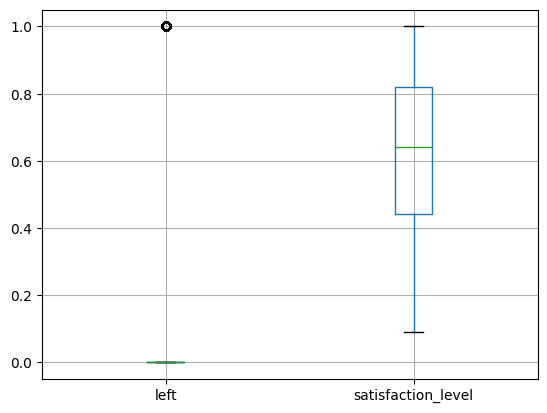

In [ ]:
## status vs satisfaction

main_df.boxplot(column = ['left','satisfaction_level'])

<Axes: >

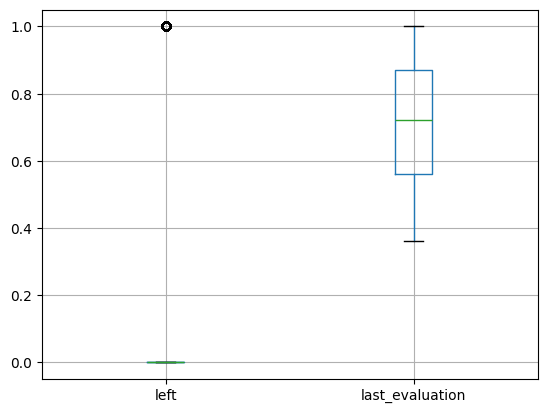

In [ ]:
## status vs last_evaluation
main_df.boxplot(column = ['left','last_evaluation'])

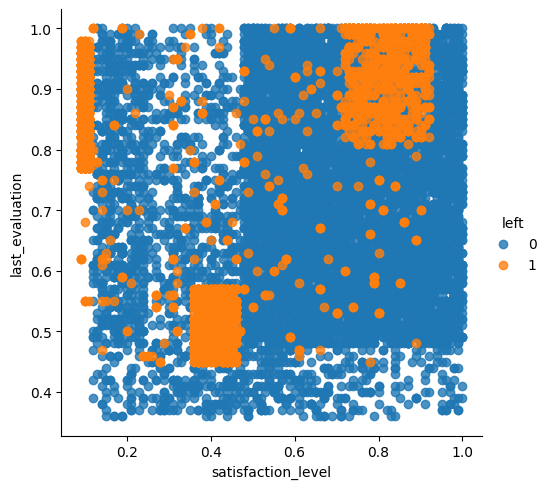

In [ ]:
import seaborn as sns
# Scatterplot of satisfaction vs. last_evaluation
sns.lmplot(x='satisfaction_level', y='last_evaluation', hue='left', data=main_df, fit_reg=False)

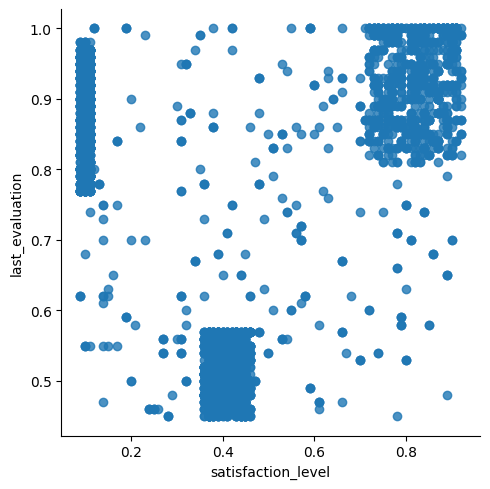

In [ ]:


# Scatterplot of satisfaction vs. last_evaluation, only those who have left
sns.lmplot(x='satisfaction_level', y='last_evaluation', data=main_df[main_df.left == 1], fit_reg=False)

In [ ]:
!pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.6/390.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 44.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=bd30c8b0e6ce58214f5f0a79737c66371cec2daf43e80efd0129ce9645be51d9
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


In [ ]:
# Assuming you have a DataFrame named main_df
from ydata_profiling import ProfileReport
profile = ProfileReport(main_df, title="Pandas Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
main_df.isnull().sum()

,0
employee_id,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0
satisfaction_level,27


In [ ]:
main_df.describe()

,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,satisfaction_level,last_evaluation
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14972.000000,14972.000000
mean,45424.627575,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,0.612830,0.716125
std,25915.900127,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,0.248714,0.171138
min,1003.000000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.090000,0.360000
25%,22872.500000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,0.440000,0.560000
50%,45448.000000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,0.640000,0.720000
75%,67480.500000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,0.820000,0.870000
max,99815.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Convert relevant columns to numeric type
for col in main_df.columns:
  try:
    main_df[col] = pd.to_numeric(main_df[col])
  except ValueError:
    print(f"Column {col} could not be converted to numeric.")

# Calculate the mean only for numeric columns
main_df.fillna(main_df.mean(numeric_only=True), inplace=True)
main_df.head(3)

Column department could not be converted to numeric.
Column salary could not be converted to numeric.


,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,satisfaction_level,last_evaluation
0,1003,2,157,3,0,1,0,sales,low,0.38,0.53
1,1005,5,262,6,0,1,0,sales,medium,0.80,0.86
2,1486,7,272,4,0,1,0,sales,medium,0.11,0.88


In [ ]:
main_df.isnull().sum()

,0
employee_id,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0
satisfaction_level,0


In [ ]:


# Removing employee ID
main_df_final = main_df.drop(['employee_id'], axis=1)
main_df_final.head()

,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,satisfaction_level,last_evaluation
0,2,157,3,0,1,0,sales,low,0.38,0.53
1,5,262,6,0,1,0,sales,medium,0.80,0.86
2,7,272,4,0,1,0,sales,medium,0.11,0.88
3,5,223,5,0,1,0,sales,low,0.72,0.87
4,2,159,3,0,1,0,sales,low,0.37,0.52


In [ ]:
main_df_final = pd.get_dummies(main_df_final, columns=['department', 'salary'])

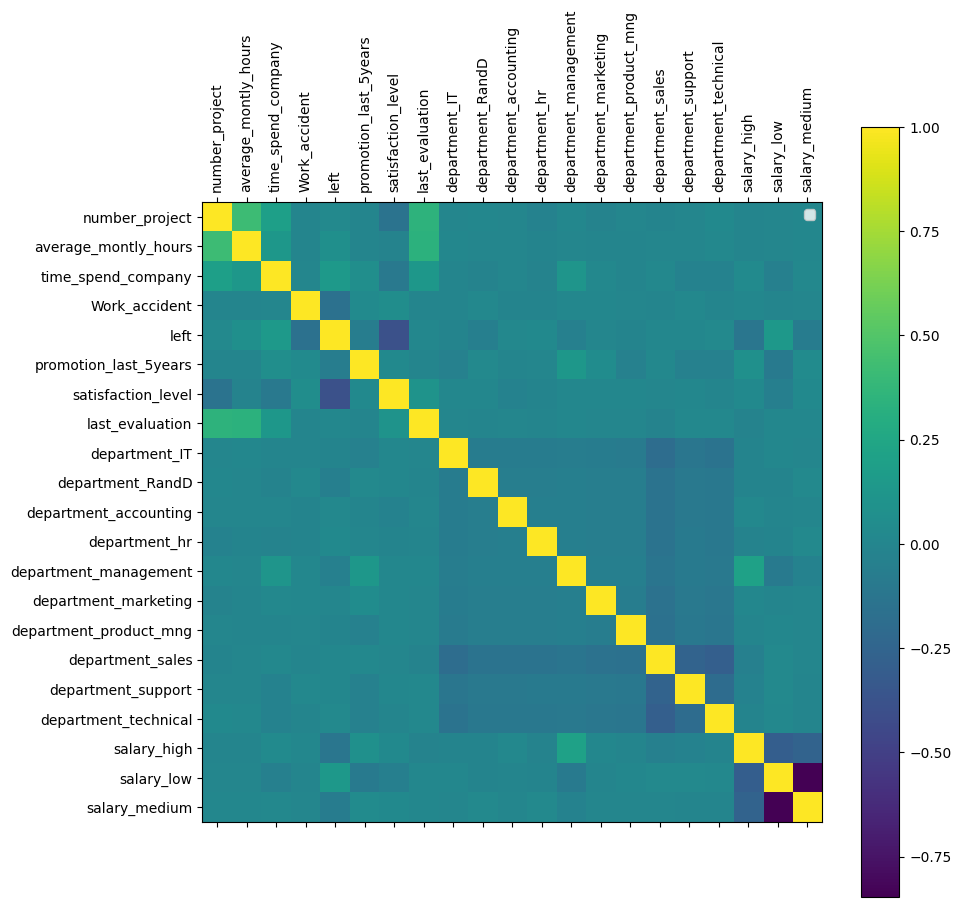

In [ ]:
import matplotlib.pyplot as plt

def plot_corr(df,size=10):

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(size, size))
    ax.legend()
    cax = ax.matshow(corr)
    fig.colorbar(cax)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation='vertical')
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.show()

plot_corr(main_df_final)

In [ ]:
#Shape of main_df_final df
main_df_final.shape

(14999, 21)

In [ ]:
# count in class
main_df_final.left.value_counts()

,count
left,
0,11428
1,3571


In [ ]:
main_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   number_project          14999 non-null  int64  
 1   average_montly_hours    14999 non-null  int64  
 2   time_spend_company      14999 non-null  int64  
 3   Work_accident           14999 non-null  int64  
 4   left                    14999 non-null  int64  
 5   promotion_last_5years   14999 non-null  int64  
 6   satisfaction_level      14999 non-null  float64
 7   last_evaluation         14999 non-null  float64
 8   department_IT           14999 non-null  bool   
 9   department_RandD        14999 non-null  bool   
 10  department_accounting   14999 non-null  bool   
 11  department_hr           14999 non-null  bool   
 12  department_management   14999 non-null  bool   
 13  department_marketing    14999 non-null  bool   
 14  department_product_mng  14999 non-null

In [ ]:
from sklearn.model_selection import train_test_split

X = main_df_final.drop(['left'],axis=1).values
y = main_df_final['left'].values

In [ ]:




# Split data into a 70:30 Ratio Train:Test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
# Normalize the data
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
df_train = pd.DataFrame(X_train)
df_train.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.961456,0.653388,-0.338839,-0.407795,-0.145957,-0.367824,1.374302,-0.298888,-0.237144,-0.229657,-0.224556,-0.2084,4.098160,-0.256054,-0.613348,-0.420108,-0.474735,-0.297752,1.022250,-0.867783
1,-0.658951,0.952595,-1.036108,-0.407795,-0.145957,-0.046569,-0.264039,-0.298888,-0.237144,-0.229657,-0.224556,-0.2084,-0.244012,-0.256054,1.630395,-0.420108,-0.474735,-0.297752,-0.978235,1.152362
2,-1.469155,-1.201695,-0.338839,-0.407795,-0.145957,-1.090647,-1.785355,-0.298888,-0.237144,-0.229657,-0.224556,-0.2084,-0.244012,-0.256054,-0.613348,-0.420108,2.106438,-0.297752,-0.978235,1.152362


In [ ]:
df_train.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04,1.049900e+04
mean,-1.316321e-16,1.610717e-16,-7.850553e-17,2.165670e-17,1.556575e-17,2.716291e-14,2.825810e-14,3.383859e-17,-7.681360e-17,6.530848e-17,5.820238e-17,6.733880e-17,3.992954e-17,-1.691930e-17,4.128308e-17,8.730357e-17,1.827284e-17,7.715199e-17,6.429332e-17,1.353544e-18
std,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00
min,-1.469155e+00,-2.099316e+00,-1.036108e+00,-4.077945e-01,-1.459572e-01,-2.094568e+00,-2.077916e+00,-2.988877e-01,-2.371443e-01,-2.296571e-01,-2.245556e-01,-2.084004e-01,-2.440119e-01,-2.560543e-01,-6.133483e-01,-4.201076e-01,-4.747352e-01,-2.977518e-01,-9.782347e-01,-8.677830e-01
25%,-6.589511e-01,-9.024883e-01,-3.388388e-01,-4.077945e-01,-1.459572e-01,-6.890785e-01,-9.076724e-01,-2.988877e-01,-2.371443e-01,-2.296571e-01,-2.245556e-01,-2.084004e-01,-2.440119e-01,-2.560543e-01,-6.133483e-01,-4.201076e-01,-4.747352e-01,-2.977518e-01,-9.782347e-01,-8.677830e-01
50%,1.512524e-01,-2.481469e-02,-3.388388e-01,-4.077945e-01,-1.459572e-01,1.140581e-01,2.852217e-02,-2.988877e-01,-2.371443e-01,-2.296571e-01,-2.245556e-01,-2.084004e-01,-2.440119e-01,-2.560543e-01,-6.133483e-01,-4.201076e-01,-4.747352e-01,-2.977518e-01,-9.782347e-01,-8.677830e-01
75%,9.614558e-01,8.728061e-01,3.584306e-01,-4.077945e-01,-1.459572e-01,8.368810e-01,9.062046e-01,-2.988877e-01,-2.371443e-01,-2.296571e-01,-2.245556e-01,-2.084004e-01,-2.440119e-01,-2.560543e-01,1.630395e+00,-4.201076e-01,-4.747352e-01,-2.977518e-01,1.022250e+00,1.152362e+00
max,2.581863e+00,2.169369e+00,4.542047e+00,2.452215e+00,6.851324e+00,1.559704e+00,1.666863e+00,3.345738e+00,4.216842e+00,4.354317e+00,4.453240e+00,4.798455e+00,4.098160e+00,3.905422e+00,1.630395e+00,2.380343e+00,2.106438e+00,3.358501e+00,1.022250e+00,1.152362e+00


In [ ]:
# Use the newest version of TensorFlow 2.0
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(9, kernel_initializer = "uniform", activation = "relu", input_dim=20))
model.add(Dense(1, kernel_initializer = "uniform", activation = "sigmoid"))

model.compile(optimizer= "adam",loss = "binary_crossentropy",metrics = ["accuracy"])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Summary and Parameters of model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 9)                   │             189 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              10 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 199 (796.00 B)

 Trainable params: 199 (796.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Check the shape of your X_train data
print(X_train.shape)

(10499, 20)


In [ ]:
# Start Training Our Classifier
batch_size = 10
epochs = 45

history = model.fit(X_train,
                    y_train,
                    batch_size = batch_size,
                    epochs = epochs,
                    verbose = 1,
                    validation_data = (X_test, y_test))

score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7750 - loss: 0.5336 - val_accuracy: 0.8400 - val_loss: 0.2999
Epoch 2/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8476 - loss: 0.2773 - val_accuracy: 0.8571 - val_loss: 0.2370
Epoch 3/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9087 - loss: 0.2381 - val_accuracy: 0.9442 - val_loss: 0.2120
Epoch 4/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9466 - loss: 0.2054 - val_accuracy: 0.9524 - val_loss: 0.1975
Epoch 5/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9471 - loss: 0.2132 - val_accuracy: 0.9551 - val_loss: 0.1890
Epoch 6/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9531 - loss: 0.1894 - val_accuracy: 0.9516 - val_loss: 0.1831
Epoch 7/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9520 - loss: 0.1850 - val_accuracy: 0.9553 - val_loss: 0.1807
Epoch 8/45
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9528 - loss: 0.1715 - 

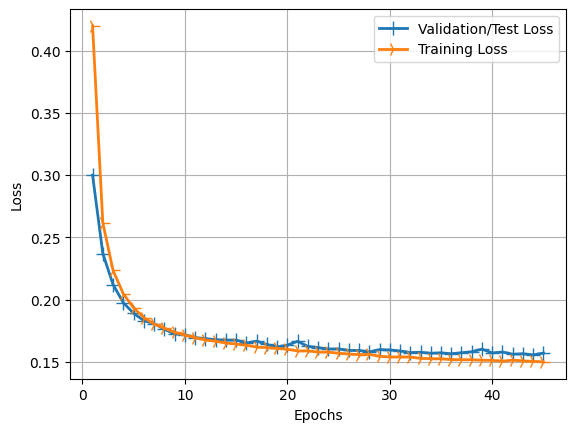

In [ ]:
# Plotting our loss charts
import matplotlib.pyplot as plt

history_dict = history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_loss_values, label='Validation/Test Loss')
line2 = plt.plot(epochs, loss_values, label='Training Loss')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

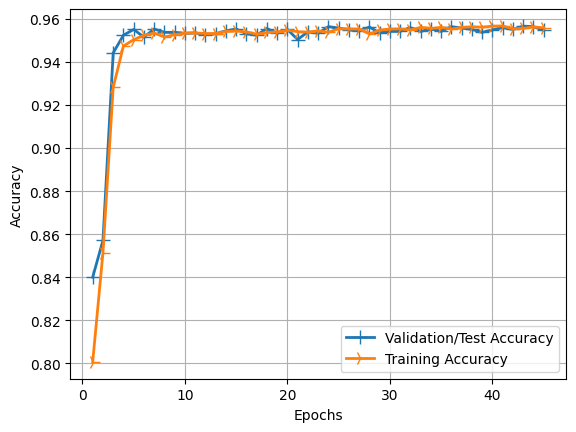

In [ ]:
# Plotting our accuracy charts
import matplotlib.pyplot as plt

history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_acc_values, label='Validation/Test Accuracy')
line2 = plt.plot(epochs, acc_values, label='Training Accuracy')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Import the confusion matrix function from sklearn
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(X_test)
predictions = (predictions > 0.5)

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[3355  103]
 [ 101  941]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3458
           1       0.90      0.90      0.90      1042

    accuracy                           0.95      4500
   macro avg       0.94      0.94      0.94      4500
weighted avg       0.95      0.95      0.95      4500



Hybrid Model


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
merged_data = pd.merge(hr_df, emp_satis_eval, left_on="employee_id", right_on="EMPLOYEE #").drop(columns=["EMPLOYEE #"])

In [ ]:
label_encoders = {
    "department": LabelEncoder().fit(merged_data["department"]),
    "salary": LabelEncoder().fit(merged_data["salary"]),
}

In [ ]:
merged_data["department"] = label_encoders["department"].transform(merged_data["department"])
merged_data["salary"] = label_encoders["salary"].transform(merged_data["salary"])

In [ ]:
# Define features and target
X = merged_data.drop(columns=["left", "employee_id"])
y = merged_data["left"]

# Normalize features
scaler = StandardScaler().fit(X)
X = scaler.transform(X)


In [ ]:
# Reshape data to 3D (samples, timesteps, features) for CNN
X = np.expand_dims(X, axis=2)  # Reshaping to (samples, features, 1)

In [ ]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Define CNN + LSTM hybrid model
def build_cnn_lstm_model(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=2, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        LSTM(50, return_sequences=True),
        Dropout(0.3),

        LSTM(30),
        Dropout(0.2),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# Train CNN + LSTM model
cnn_lstm_model = build_cnn_lstm_model((X_train.shape[1], 1))
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = cnn_lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7173 - loss: nan - val_accuracy: 0.7629 - val_loss: nan
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7612 - loss: nan - val_accuracy: 0.7629 - val_loss: nan
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7643 - loss: nan - val_accuracy: 0.7629 - val_loss: nan
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7637 - loss: nan - val_accuracy: 0.7629 - val_loss: nan
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7683 - loss: nan - val_accuracy: 0.7629 - val_loss: nan


In [ ]:
# Ensemble with Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train.squeeze(), y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict and ensemble
cnn_lstm_preds = cnn_lstm_model.predict(X_test)
rf_preds = rf_model.predict(X_test.squeeze())

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
# Combine predictions with Logistic Regression
stacked_features = np.column_stack((cnn_lstm_preds, rf_preds))

# Impute NaN values with the mean
imputer = SimpleImputer(strategy='mean') # Create an imputer instance
stacked_features = imputer.fit_transform(stacked_features) # Fit and transform the data to replace NaN
meta_model = LogisticRegression()
meta_model.fit(stacked_features, y_test)
final_preds = meta_model.predict(stacked_features)

/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: [0]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, final_preds)
print(f"Ensemble Model Test Accuracy: {accuracy:.4f}")

Ensemble Model Test Accuracy: 0.9887


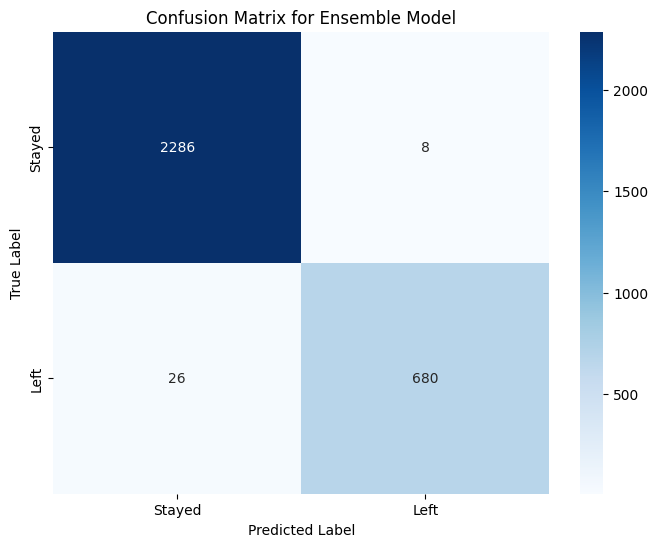

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, final_preds)

# Display the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Ensemble Model")
plt.show()

In [ ]:
# Preprocessing function for new input
def preprocess_input(new_data):
    # Get the feature names used during training
    original_features = scaler.feature_names_in_  # Assuming scaler is your StandardScaler/MinMaxScaler object

    # Ensure new_data has the same columns in the same order
    new_data = new_data[original_features]

    # Encode categorical columns, handling unknown labels
    new_data["department"] = label_encoders["department"].transform(new_data["department"].astype(str))
    new_data["salary"] = label_encoders["salary"].transform(new_data["salary"].astype(str)) # Apply the same handling for salary

    # Scale the data
    new_data_scaled = scaler.transform(new_data)

    # Reshape for CNN-LSTM input
    return np.expand_dims(new_data_scaled, axis=2)  # Shape: (1, features, 1)

In [ ]:
# Example new data sample for prediction
new_data = pd.DataFrame({
    "satisfaction_level": [0.8],
    "last_evaluation": [0.6],
    "number_project": [3],
    "average_montly_hours": [150],
    "time_spend_company": [3],
    "Work_accident": [0],
    "promotion_last_5years": [0],
    "department": ["sales"],
    "salary": ["low"]
})

In [ ]:
# Preprocess new data
preprocessed_data = preprocess_input(new_data)


In [ ]:
# Get predictions from CNN-LSTM and Random Forest models
cnn_lstm_pred = (cnn_lstm_model.predict(preprocessed_data) > 0.5).astype("int32").flatten()

# Reshape the preprocessed data for Random Forest
rf_pred = rf_model.predict(preprocessed_data.squeeze().reshape(1, -1)) # Reshape to (1, features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
# Combine predictions and use the meta-model for the final prediction
stacked_features_new = rf_pred.reshape(1, -1)
final_pred = meta_model.predict(stacked_features_new)

# Output final prediction
print(f"Predicted class for new input: {'Left' if final_pred[0] == 1 else 'Stayed'}")

Predicted class for new input: Stayed
